# Data Understanding: E-commerce Customer Behavior Analysis

## Overview

This notebook provides comprehensive exploratory data analysis (EDA) of the cleaned e-commerce dataset to understand customer behavior, product patterns, and business metrics. The analysis supports cohort analysis and time series forecasting for LTV and ROMI optimization.

## Analysis Objectives

1. **Customer Behavior Understanding**: Purchase patterns, frequency, and value
2. **Product Analysis**: Popular products, categories, and pricing
3. **Temporal Patterns**: Seasonal trends, peak periods, and time-based insights
4. **Geographic Analysis**: Country-wise performance and customer distribution
5. **Business Metrics**: Revenue analysis, returns patterns, and key KPIs
6. **Correlation Analysis**: Relationships between variables
7. **Outlier Identification**: Anomalous patterns and data quality checks

## Dataset Information

- **Source**: Cleaned e-commerce transaction data (2009-2011)
- **Records**: ~798K transactions from 5,362 customers
- **Time Period**: 738 days (Dec 2009 - Dec 2011)
- **Key Variables**: Customer ID, Invoice, StockCode, Quantity, Price, Country, Date features

## Analysis Sections

1. **Data Loading and Basic Overview**
2. **Univariate Analysis** (Individual variable distributions)
3. **Bivariate Analysis** (Variable relationships)
4. **Time Series Analysis** (Temporal patterns)
5. **Customer Segmentation** (RFM-like analysis)
6. **Product Analysis** (Popular items and categories)
7. **Geographic Analysis** (Country performance)
8. **Business Insights** (Key findings and recommendations)

In [16]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print(f"Current date/time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Current date/time: 2026-04-12 20:16:12


In [15]:
# Data Loading
print("=== DATA LOADING ===")

# Load the cleaned dataset
data_path = 'data/cleaned/online_retail_cleaned_full.csv'

try:
    df = pd.read_csv(data_path, parse_dates=['InvoiceDate', 'FirstPurchaseDate'])
    print(f"  - Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  - Memory usage: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

    # Display basic info
    print(f"\nData types:")
    print(df.dtypes)

    print(f"\nFirst 5 rows:")
    display(df.head())

except Exception as e:
    print(f"✗ Error loading data: {e}")
    raise

# Create working copies for different analyses
df_sales = df[df['Quantity'] > 0].copy()  # Only sales transactions
df_returns = df[df['Quantity'] < 0].copy()  # Only returns

print(f"\nDataset splits:")
print(f"- All transactions: {len(df):,}")
print(f"- Sales only: {len(df_sales):,}")
print(f"- Returns only: {len(df_returns):,}")

# Key date information
print(f"\nDate range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Total days: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days")

=== DATA LOADING ===
  - Shape: 797,885 rows × 28 columns
  - Memory usage: 227.37 MB

Data types:
Invoice                          str
StockCode                        str
Description                      str
Quantity                       int64
InvoiceDate           datetime64[us]
Price                        float64
Customer ID                    int64
Country                          str
IsReturn                        bool
TotalValue                   float64
Year                           int64
Month                          int64
Day                            int64
Hour                           int64
DayOfWeek                      int64
DayOfWeekName                    str
MonthYear                        str
Quarter                        int64
FirstPurchaseDate     datetime64[us]
CohortYear                     int64
CohortMonth                    int64
CohortQuarter                  int64
CohortMonthYear                  str
CohortIndex                    int64
PositiveQuant

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsReturn,TotalValue,...,FirstPurchaseDate,CohortYear,CohortMonth,CohortQuarter,CohortMonthYear,CohortIndex,PositiveQuantity,PositiveTotalValue,InvoiceType,ProductCategory
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,83.4,...,2009-12-01 07:45:00,2009,12,4,2009-12,0,12,83.4,Sale,Decoration
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,81.0,...,2009-12-01 07:45:00,2009,12,4,2009-12,0,12,81.0,Sale,Decoration
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,81.0,...,2009-12-01 07:45:00,2009,12,4,2009-12,0,12,81.0,Sale,Decoration
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,100.8,...,2009-12-01 07:45:00,2009,12,4,2009-12,0,48,100.8,Sale,Other
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,30.0,...,2009-12-01 07:45:00,2009,12,4,2009-12,0,24,30.0,Sale,Other



Dataset splits:
- All transactions: 797,885
- Sales only: 779,495
- Returns only: 18,390

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Total days: 738 days


=== UNIVARIATE ANALYSIS ===

1. TRANSACTION VALUE ANALYSIS
count    797885.000000
mean         20.416465
std         313.518824
min     -168469.600000
25%           4.350000
50%          11.700000
75%          19.500000
max      168469.600000
Name: TotalValue, dtype: float64


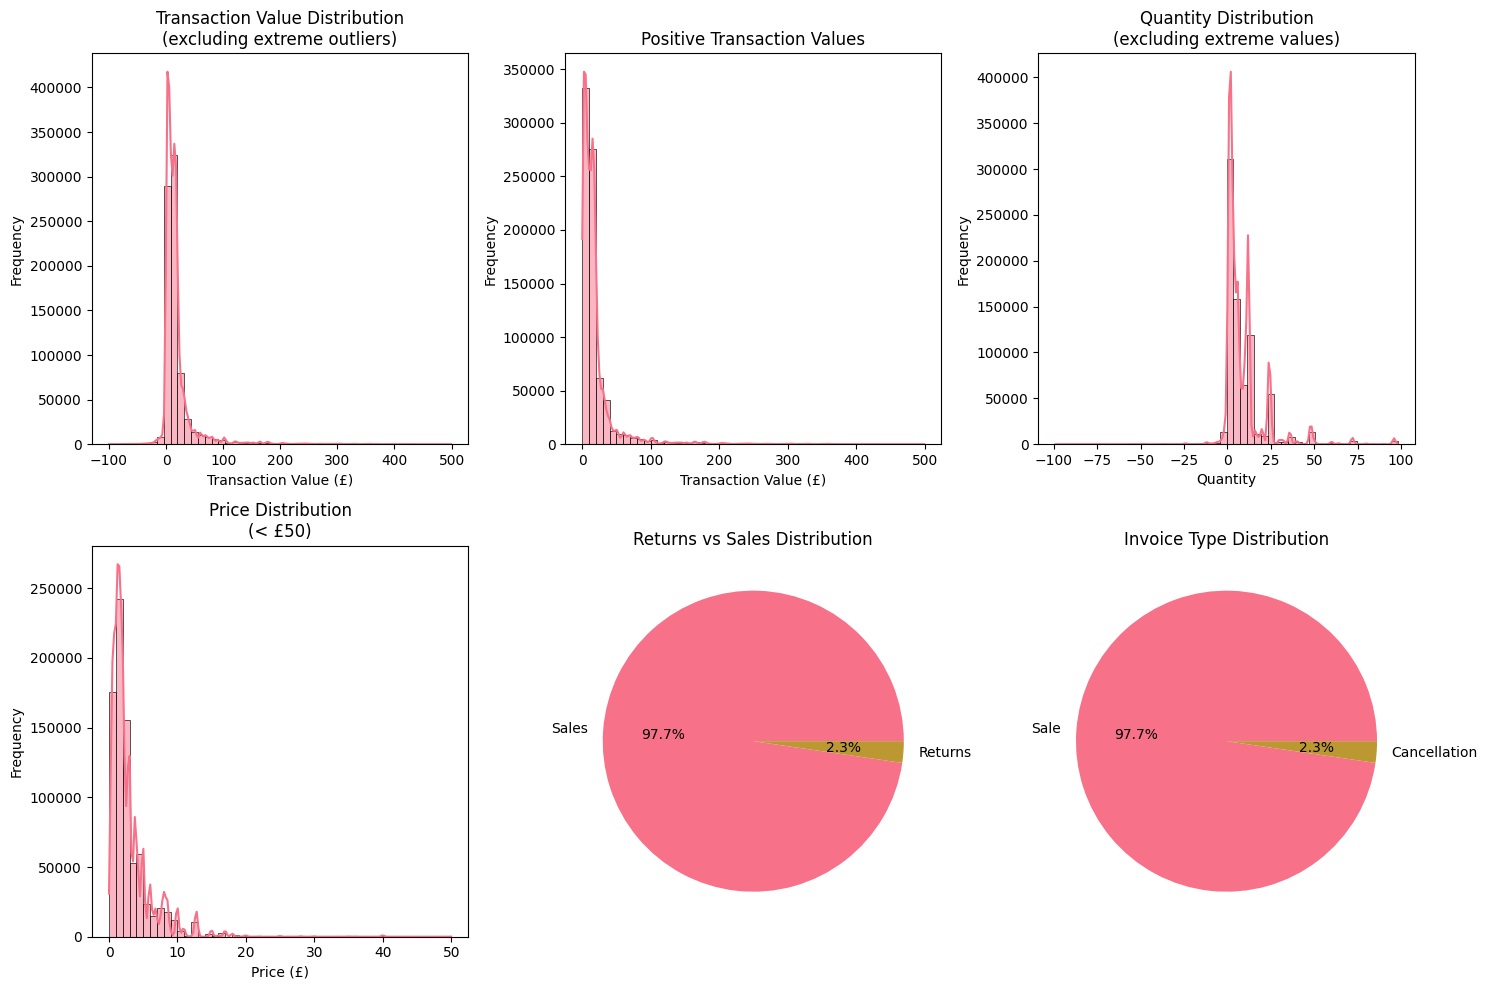


2. CUSTOMER ANALYSIS
Customer statistics:
       NumInvoices     TotalSpend     TotalItems
count  5942.000000    5942.000000    5942.000000
mean      7.552339    2741.499712    1851.511444
std      15.972262   13676.639629    9545.835998
min       1.000000  -25111.090000       1.000000
25%       2.000000     321.065000     183.000000
50%       4.000000     822.010000     479.000000
75%       8.000000    2142.195000    1360.500000
max     510.000000  570380.610000  370446.000000


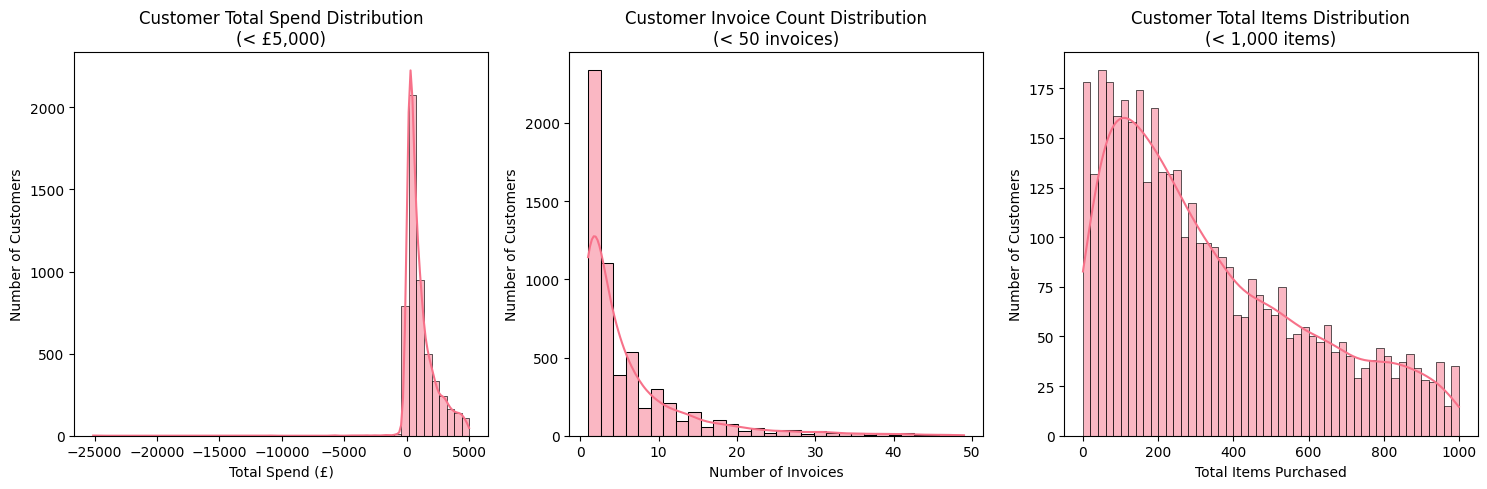


3. PRODUCT ANALYSIS
Top 10 products by revenue:


,StockCode,Description,TotalRevenue,TotalQuantity,UniqueCustomers
1609,22423,REGENCY CAKESTAND 3 TIER,277656.25,24139,1314
4080,85123A,WHITE HANGING HEART T-LIGHT HOLDER,247203.36,91814,1490
2726,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
4058,85099B,JUMBO BAG RED WHITE SPOTTY,167920.64,93436,978
4625,M,Manual,151777.67,9391,443
4627,POST,POSTAGE,124648.04,5235,405
3819,84879,ASSORTED COLOUR BIRD ORNAMENT,124351.86,78234,1010
3059,47566,PARTY BUNTING,103283.38,23464,894
2324,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,138
1298,22086,PAPER CHAIN KIT 50'S CHRISTMAS,76598.18,28380,896



Top 10 products by quantity sold:


,StockCode,Description,TotalRevenue,TotalQuantity,UniqueCustomers
3410,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,24098.03,105185,482
4058,85099B,JUMBO BAG RED WHITE SPOTTY,167920.64,93436,978
4080,85123A,WHITE HANGING HEART T-LIGHT HOLDER,247203.36,91814,1490
601,21212,PACK OF 72 RETRO SPOT CAKE CASES,43390.03,89850,1115
2726,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3819,84879,ASSORTED COLOUR BIRD ORNAMENT,124351.86,78234,1010
2324,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,138
1405,22197,"POPCORN HOLDER , SMALL",58267.74,76944,601
108,17003,BROCADE RING PURSE,14640.96,70082,215
1219,21977,PACK OF 60 PINK PAISLEY CAKE CASES,26407.35,54592,767


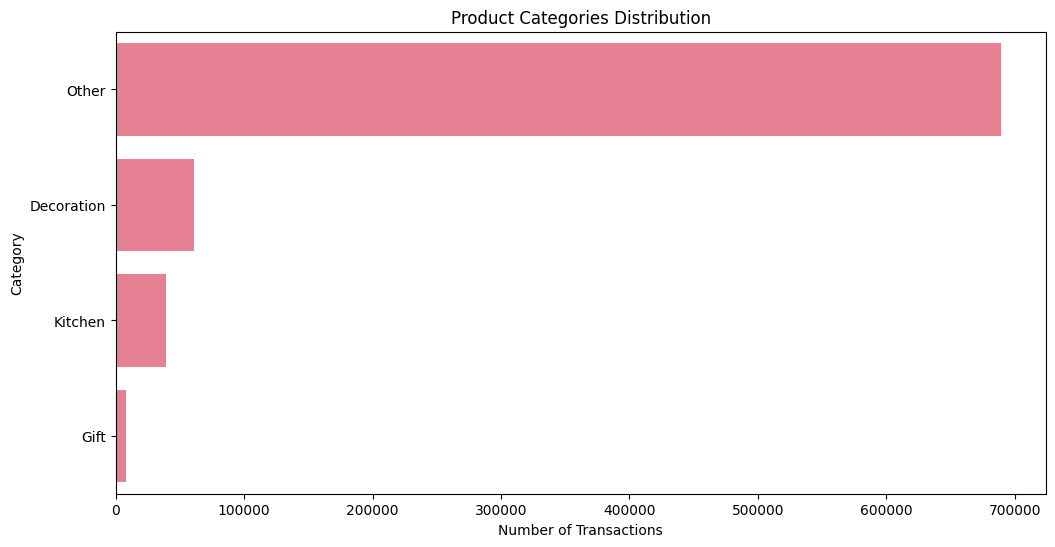

In [11]:
# Univariate Analysis: Individual Variable Distributions
print("=== UNIVARIATE ANALYSIS ===")

# 1. Transaction Value Analysis
print("\n1. TRANSACTION VALUE ANALYSIS")
print(df['TotalValue'].describe())

plt.figure(figsize=(15, 10))

# Transaction value distribution (excluding extreme outliers)
plt.subplot(2, 3, 1)
value_data = df['TotalValue'][(df['TotalValue'] > -100) & (df['TotalValue'] < 500)]
sns.histplot(value_data, bins=50, kde=True)
plt.title('Transaction Value Distribution\n(excluding extreme outliers)')
plt.xlabel('Transaction Value (£)')
plt.ylabel('Frequency')

# Positive transaction values only
plt.subplot(2, 3, 2)
positive_values = df_sales['TotalValue'][df_sales['TotalValue'] < 500]
sns.histplot(positive_values, bins=50, kde=True)
plt.title('Positive Transaction Values')
plt.xlabel('Transaction Value (£)')
plt.ylabel('Frequency')

# Quantity distribution
plt.subplot(2, 3, 3)
qty_data = df['Quantity'][abs(df['Quantity']) < 100]
sns.histplot(qty_data, bins=50, kde=True)
plt.title('Quantity Distribution\n(excluding extreme values)')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

# Price distribution
plt.subplot(2, 3, 4)
price_data = df['Price'][df['Price'] < 50]
sns.histplot(price_data, bins=50, kde=True)
plt.title('Price Distribution\n(< £50)')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')

# Returns vs Sales
plt.subplot(2, 3, 5)
return_counts = df['IsReturn'].value_counts()
plt.pie(return_counts.values, labels=['Sales', 'Returns'], autopct='%1.1f%%')
plt.title('Returns vs Sales Distribution')

# Invoice type distribution
plt.subplot(2, 3, 6)
invoice_types = df['InvoiceType'].value_counts()
plt.pie(invoice_types.values, labels=invoice_types.index, autopct='%1.1f%%')
plt.title('Invoice Type Distribution')

plt.tight_layout()
plt.show()

# 2. Customer Analysis
print("\n2. CUSTOMER ANALYSIS")
customer_stats = df.groupby('Customer ID').agg({
    'Invoice': 'nunique',  # Number of invoices
    'TotalValue': 'sum',   # Total spend
    'Quantity': lambda x: abs(x).sum(),  # Total items purchased
    'InvoiceDate': ['min', 'max']  # First and last purchase
}).reset_index()

customer_stats.columns = ['CustomerID', 'NumInvoices', 'TotalSpend', 'TotalItems', 'FirstPurchase', 'LastPurchase']

print(f"Customer statistics:")
print(customer_stats[['NumInvoices', 'TotalSpend', 'TotalItems']].describe())

# Customer spending distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
spend_data = customer_stats['TotalSpend'][customer_stats['TotalSpend'] < 5000]
sns.histplot(spend_data, bins=50, kde=True)
plt.title('Customer Total Spend Distribution\n(< £5,000)')
plt.xlabel('Total Spend (£)')
plt.ylabel('Number of Customers')

plt.subplot(1, 3, 2)
invoice_data = customer_stats['NumInvoices'][customer_stats['NumInvoices'] < 50]
sns.histplot(invoice_data, bins=30, kde=True)
plt.title('Customer Invoice Count Distribution\n(< 50 invoices)')
plt.xlabel('Number of Invoices')
plt.ylabel('Number of Customers')

plt.subplot(1, 3, 3)
item_data = customer_stats['TotalItems'][customer_stats['TotalItems'] < 1000]
sns.histplot(item_data, bins=50, kde=True)
plt.title('Customer Total Items Distribution\n(< 1,000 items)')
plt.xlabel('Total Items Purchased')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

# 3. Product Analysis
print("\n3. PRODUCT ANALYSIS")
product_stats = df_sales.groupby('StockCode').agg({
    'Description': 'first',
    'Quantity': 'sum',
    'TotalValue': 'sum',
    'Customer ID': 'nunique'
}).reset_index()

product_stats.columns = ['StockCode', 'Description', 'TotalQuantity', 'TotalRevenue', 'UniqueCustomers']

print(f"Top 10 products by revenue:")
display(product_stats.nlargest(10, 'TotalRevenue')[['StockCode', 'Description', 'TotalRevenue', 'TotalQuantity', 'UniqueCustomers']])

print(f"\nTop 10 products by quantity sold:")
display(product_stats.nlargest(10, 'TotalQuantity')[['StockCode', 'Description', 'TotalRevenue', 'TotalQuantity', 'UniqueCustomers']])

# Product category analysis
plt.figure(figsize=(12, 6))
category_counts = df['ProductCategory'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.title('Product Categories Distribution')
plt.xlabel('Number of Transactions')
plt.ylabel('Category')
plt.show()

=== BIVARIATE ANALYSIS ===

1. CORRELATION ANALYSIS


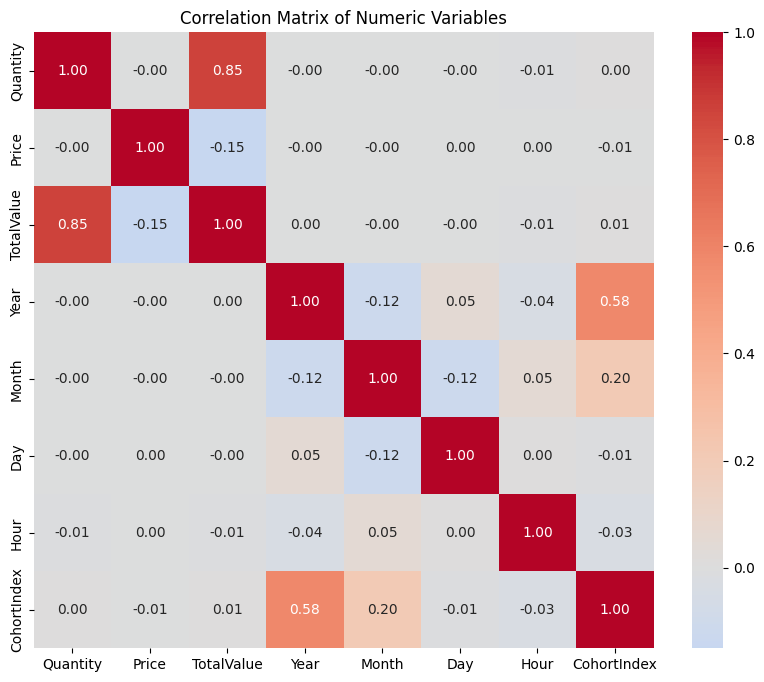


2. PRICE VS QUANTITY ANALYSIS


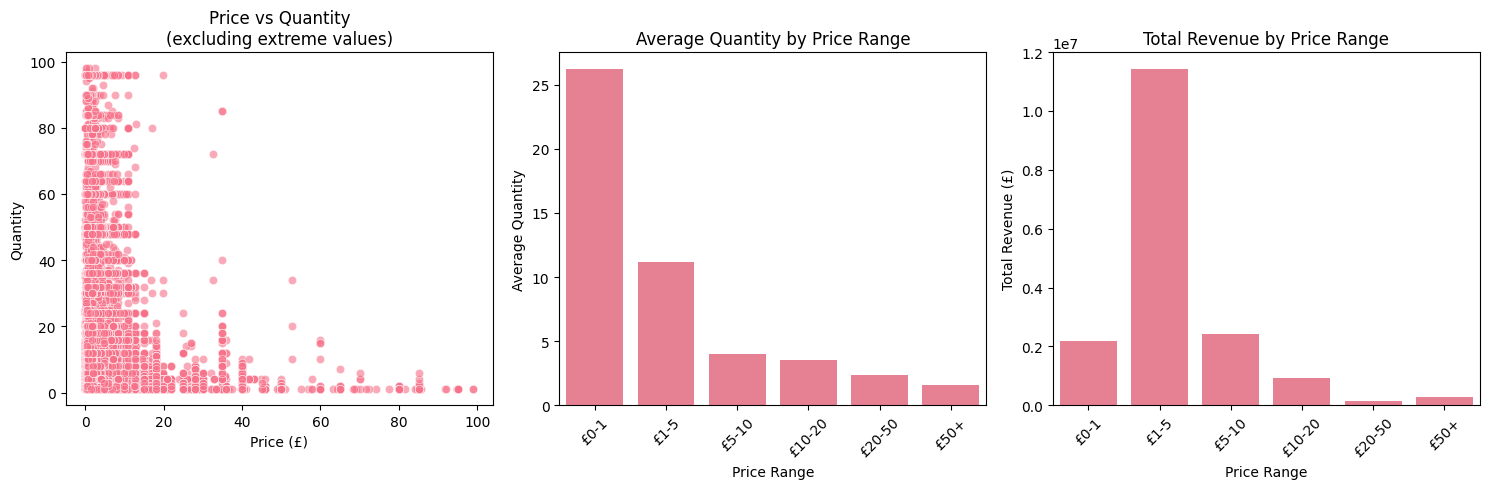


3. CUSTOMER BEHAVIOR ANALYSIS
RFM Analysis Summary:
         CustomerID      Recency    Frequency       Monetary
count   5942.000000  5942.000000  5942.000000    5942.000000
mean   15316.500000   201.908617     7.552339    2741.499712
std     1715.451981   211.857936    15.972262   13676.639629
min    12346.000000     0.000000     1.000000  -25111.090000
25%    13831.250000    24.000000     2.000000     321.065000
50%    15316.500000    95.000000     4.000000     822.010000
75%    16801.750000   380.000000     8.000000    2142.195000
max    18287.000000   738.000000   510.000000  570380.610000


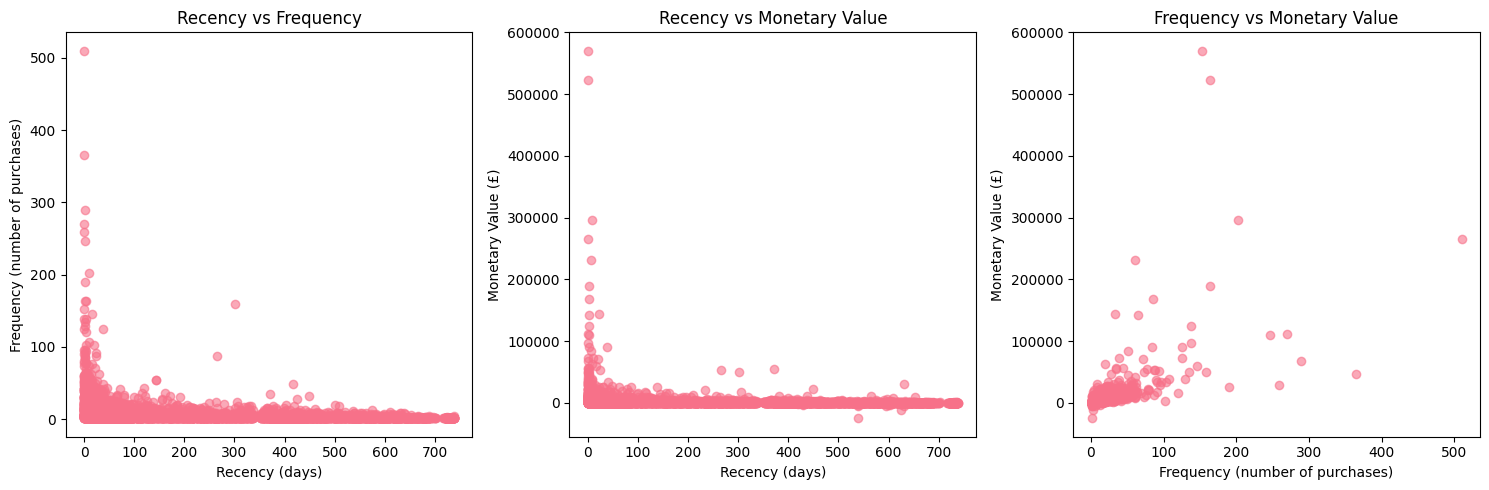


4. GEOGRAPHIC ANALYSIS
Top 10 countries by revenue:


,Country,TotalRevenue,UniqueCustomers,NumInvoices
38,United Kingdom,1.438923e+07,5353,33546
10,EIRE,6.165705e+05,5,567
24,Netherlands,5.540381e+05,22,229
14,Germany,4.250197e+05,107,789
13,France,3.487690e+05,95,614
0,Australia,1.692835e+05,15,95
32,Spain,1.083325e+05,41,154
34,Switzerland,1.000619e+05,22,90
33,Sweden,9.151582e+04,19,104
9,Denmark,6.858069e+04,12,43


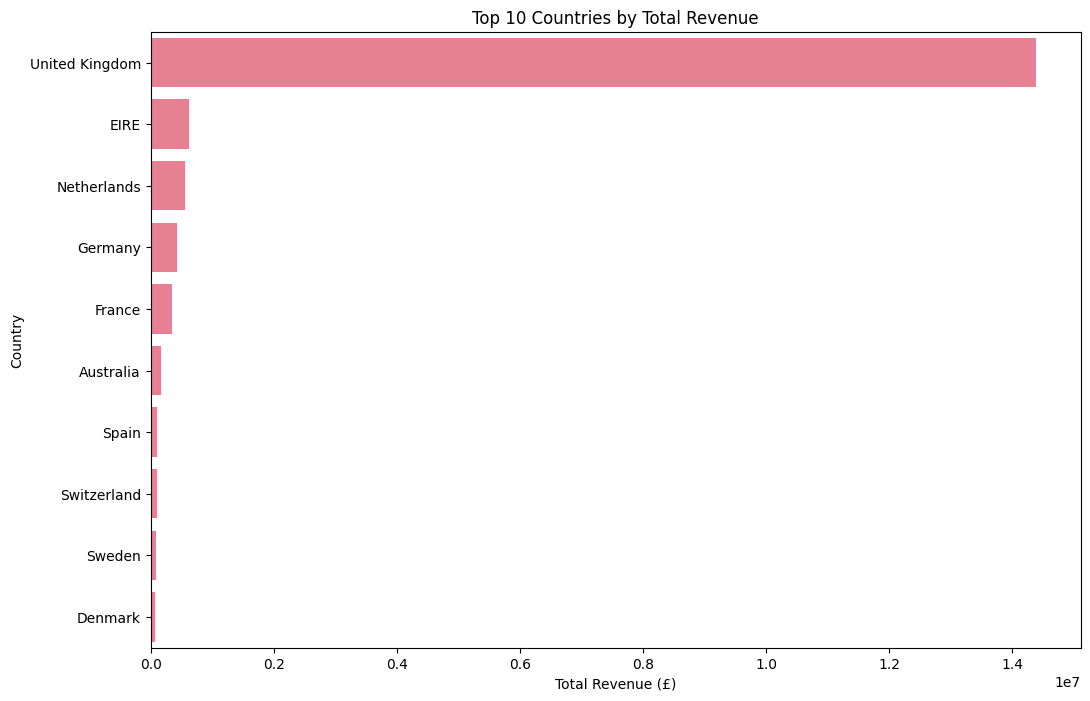

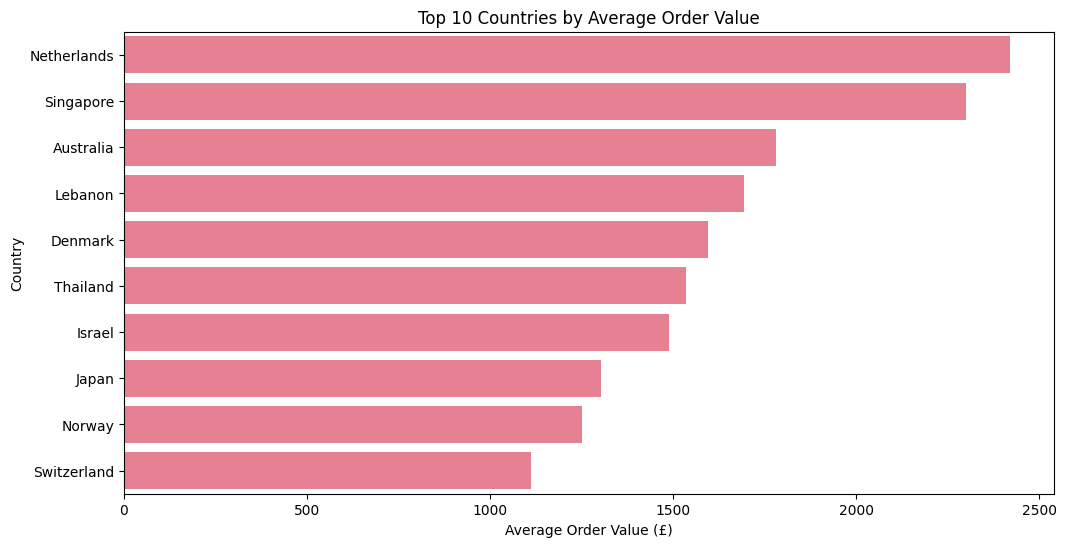

In [12]:
# Bivariate Analysis: Variable Relationships
print("=== BIVARIATE ANALYSIS ===")

# 1. Correlation Analysis
print("\n1. CORRELATION ANALYSIS")
# Select numeric columns for correlation
numeric_cols = ['Quantity', 'Price', 'TotalValue', 'Year', 'Month', 'Day', 'Hour', 'CohortIndex']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

# 2. Price vs Quantity Relationship
print("\n2. PRICE VS QUANTITY ANALYSIS")
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
# Scatter plot with limited range to avoid outliers
plot_data = df_sales[(df_sales['Price'] < 100) & (abs(df_sales['Quantity']) < 100)]
sns.scatterplot(data=plot_data, x='Price', y='Quantity', alpha=0.6)
plt.title('Price vs Quantity\n(excluding extreme values)')
plt.xlabel('Price (£)')
plt.ylabel('Quantity')

plt.subplot(1, 3, 2)
# Average quantity by price ranges
df_sales['PriceRange'] = pd.cut(df_sales['Price'],
                               bins=[0, 1, 5, 10, 20, 50, float('inf')],
                               labels=['£0-1', '£1-5', '£5-10', '£10-20', '£20-50', '£50+'])
avg_qty_by_price = df_sales.groupby('PriceRange')['Quantity'].mean().reset_index()
sns.barplot(data=avg_qty_by_price, x='PriceRange', y='Quantity')
plt.title('Average Quantity by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Average Quantity')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
# Revenue by price ranges
revenue_by_price = df_sales.groupby('PriceRange')['TotalValue'].sum().reset_index()
sns.barplot(data=revenue_by_price, x='PriceRange', y='TotalValue')
plt.title('Total Revenue by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 3. Customer Behavior Analysis
print("\n3. CUSTOMER BEHAVIOR ANALYSIS")

# Recency, Frequency, Monetary (RFM-like analysis)
current_date = df['InvoiceDate'].max()

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (current_date - x.max()).days,  # Recency
    'Invoice': 'nunique',  # Frequency
    'TotalValue': 'sum'   # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("RFM Analysis Summary:")
print(rfm.describe())

# RFM Scatter plots
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(rfm['Recency'], rfm['Frequency'], alpha=0.6)
plt.title('Recency vs Frequency')
plt.xlabel('Recency (days)')
plt.ylabel('Frequency (number of purchases)')

plt.subplot(1, 3, 2)
plt.scatter(rfm['Recency'], rfm['Monetary'], alpha=0.6)
plt.title('Recency vs Monetary Value')
plt.xlabel('Recency (days)')
plt.ylabel('Monetary Value (£)')

plt.subplot(1, 3, 3)
plt.scatter(rfm['Frequency'], rfm['Monetary'], alpha=0.6)
plt.title('Frequency vs Monetary Value')
plt.xlabel('Frequency (number of purchases)')
plt.ylabel('Monetary Value (£)')

plt.tight_layout()
plt.show()

# 4. Country vs Revenue Analysis
print("\n4. GEOGRAPHIC ANALYSIS")
country_revenue = df_sales.groupby('Country').agg({
    'TotalValue': 'sum',
    'Customer ID': 'nunique',
    'Invoice': 'nunique'
}).reset_index()

country_revenue.columns = ['Country', 'TotalRevenue', 'UniqueCustomers', 'NumInvoices']
country_revenue = country_revenue.sort_values('TotalRevenue', ascending=False)

print("Top 10 countries by revenue:")
display(country_revenue.head(10))

plt.figure(figsize=(12, 8))
top_countries = country_revenue.head(10)
sns.barplot(data=top_countries, y='Country', x='TotalRevenue')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.show()

# Average order value by country
country_revenue['AvgOrderValue'] = country_revenue['TotalRevenue'] / country_revenue['NumInvoices']
top_aov = country_revenue.nlargest(10, 'AvgOrderValue')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_aov, y='Country', x='AvgOrderValue')
plt.title('Top 10 Countries by Average Order Value')
plt.xlabel('Average Order Value (£)')
plt.ylabel('Country')
plt.show()

=== TIME SERIES ANALYSIS ===

1. DAILY SALES TRENDS


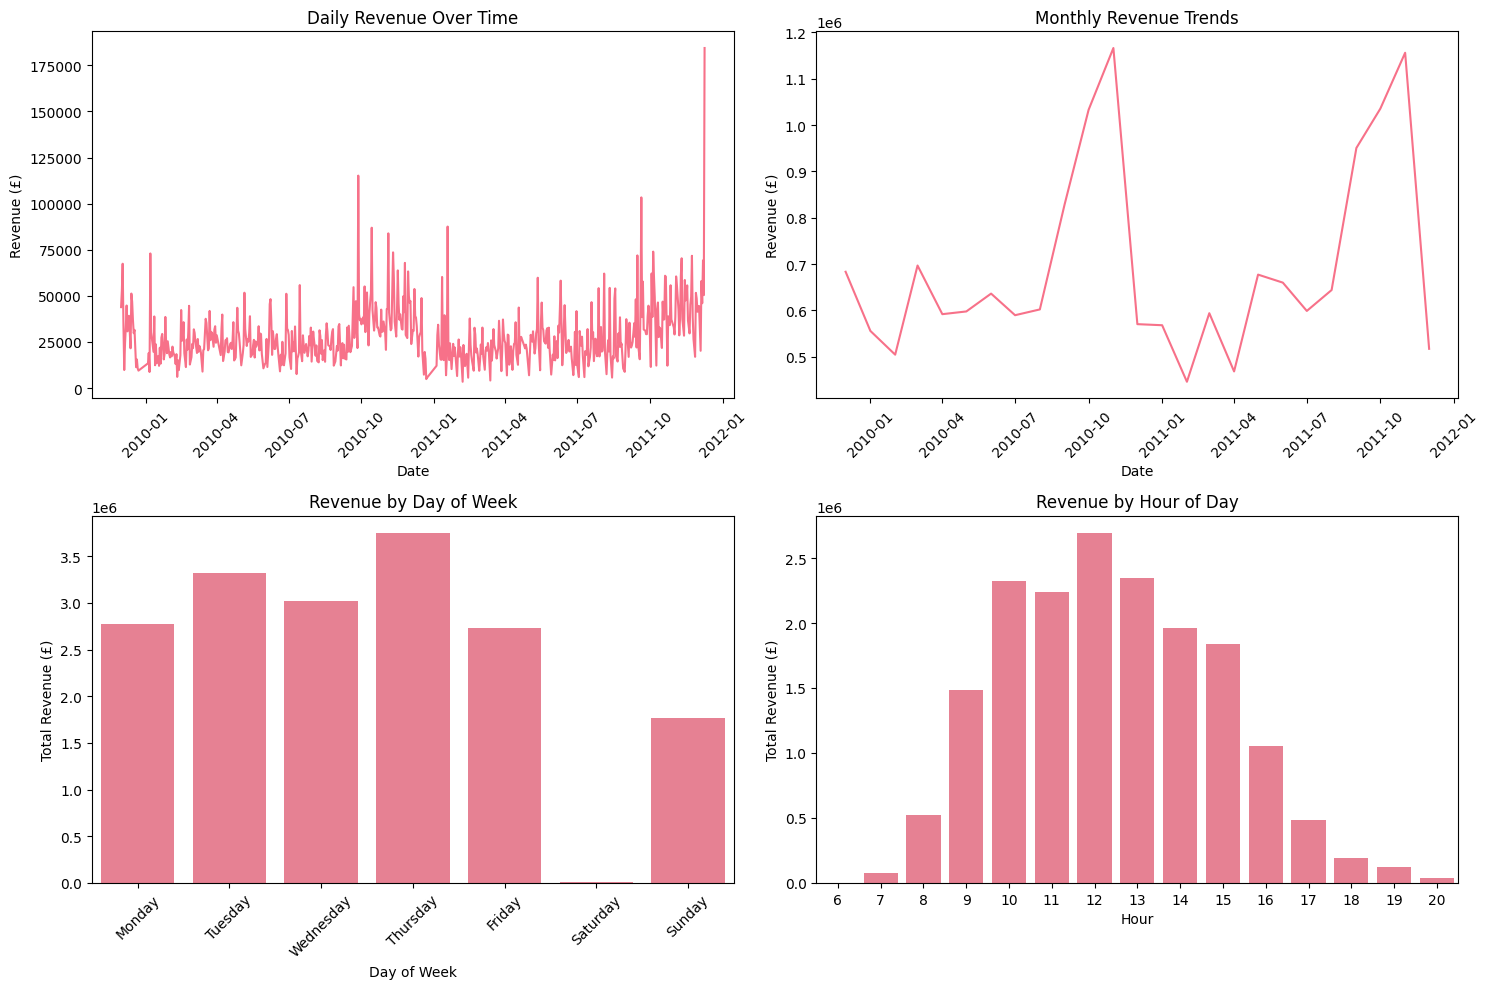


2. SEASONAL ANALYSIS


<Figure size 1200x600 with 0 Axes>

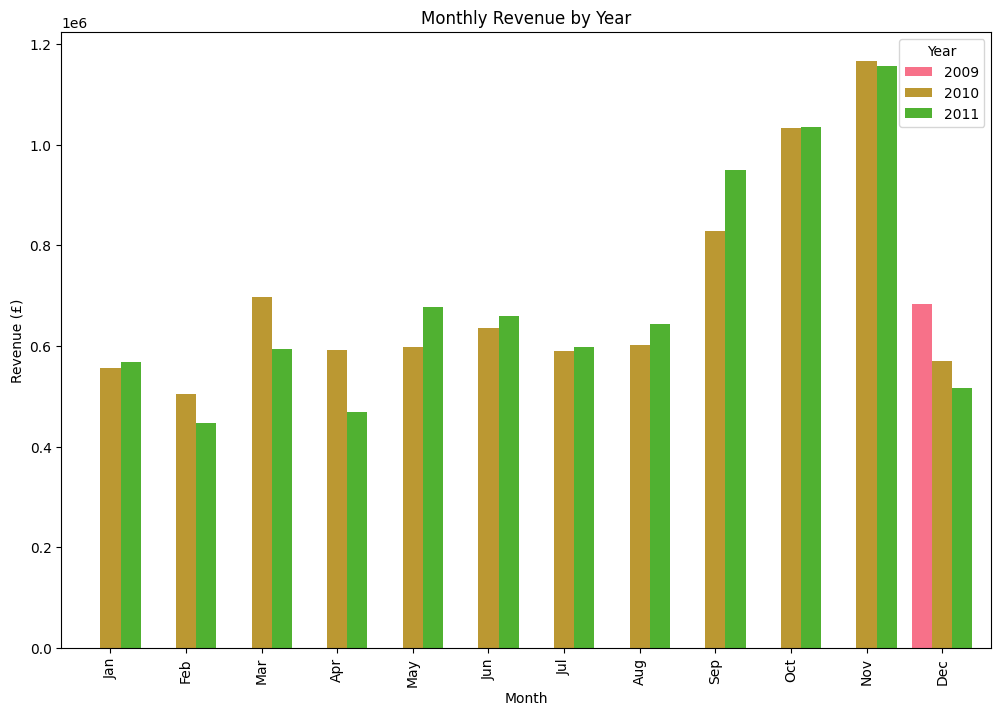

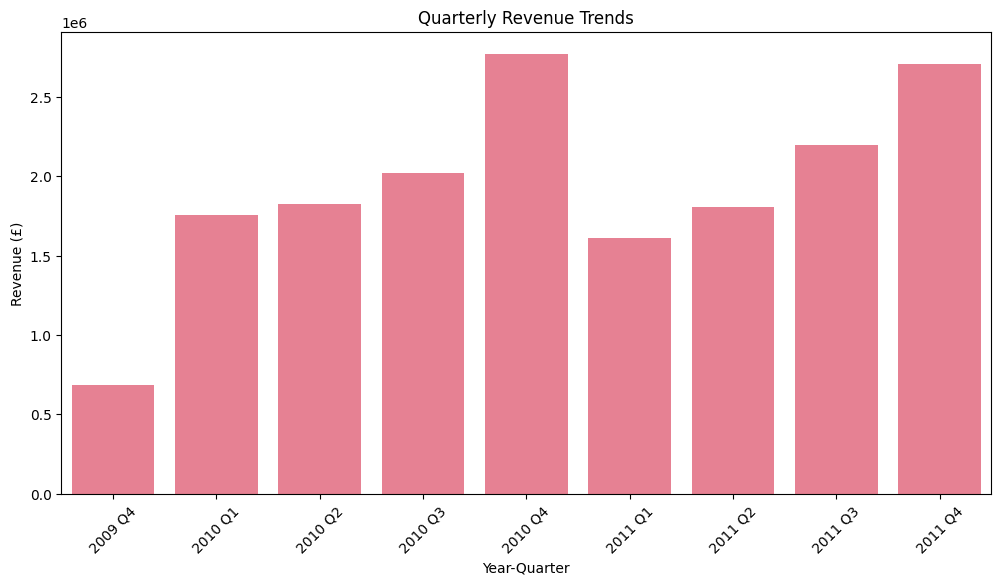


3. CUSTOMER ACQUISITION TRENDS


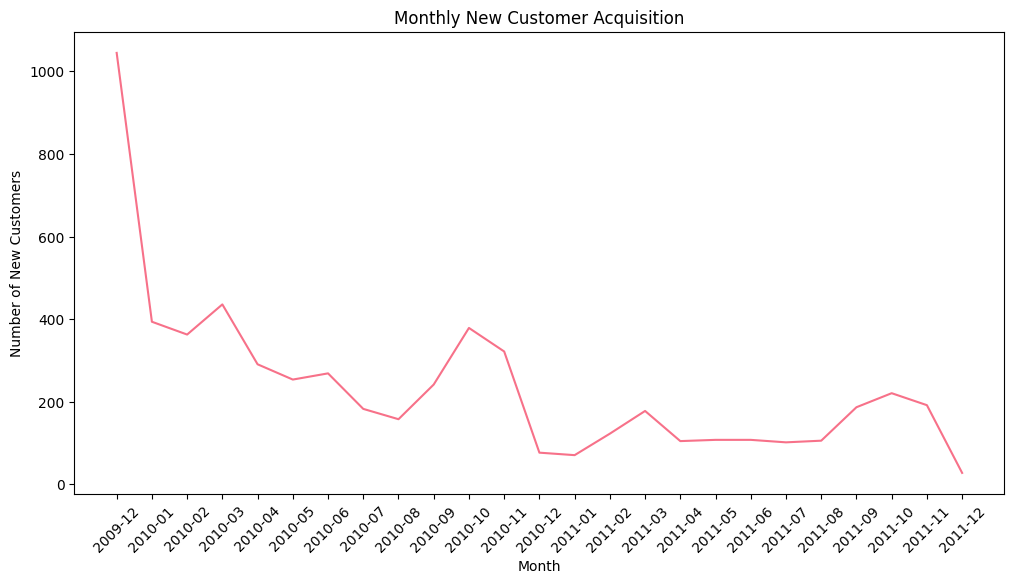


4. COHORT ANALYSIS PREVIEW


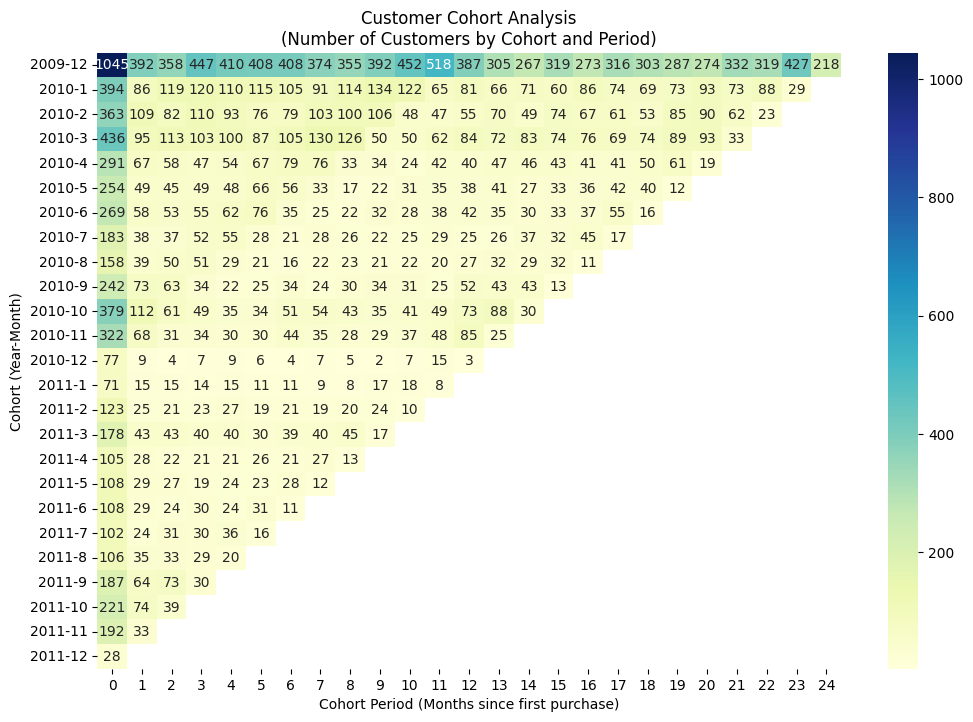

In [13]:
# Time Series Analysis: Temporal Patterns
print("=== TIME SERIES ANALYSIS ===")

# 1. Daily Sales Trends
print("\n1. DAILY SALES TRENDS")
daily_sales = df_sales.groupby(df_sales['InvoiceDate'].dt.date)['TotalValue'].sum().reset_index()
daily_sales.columns = ['Date', 'DailyRevenue']
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(daily_sales['Date'], daily_sales['DailyRevenue'])
plt.title('Daily Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)

# 2. Monthly Sales Trends
monthly_sales = df_sales.groupby(['Year', 'Month'])['TotalValue'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(DAY=1))

plt.subplot(2, 2, 2)
plt.plot(monthly_sales['Date'], monthly_sales['TotalValue'])
plt.title('Monthly Revenue Trends')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)

# 3. Weekly Patterns
weekly_sales = df_sales.groupby('DayOfWeek')['TotalValue'].sum().reset_index()
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_sales['DayName'] = weekly_sales['DayOfWeek'].map(dict(enumerate(day_names)))

plt.subplot(2, 2, 3)
sns.barplot(data=weekly_sales, x='DayName', y='TotalValue')
plt.title('Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)

# 4. Hourly Patterns
hourly_sales = df_sales.groupby('Hour')['TotalValue'].sum().reset_index()

plt.subplot(2, 2, 4)
sns.barplot(data=hourly_sales, x='Hour', y='TotalValue')
plt.title('Revenue by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Total Revenue (£)')

plt.tight_layout()
plt.show()

# 5. Seasonal Analysis
print("\n2. SEASONAL ANALYSIS")

# Monthly patterns by year
monthly_by_year = df_sales.pivot_table(
    values='TotalValue',
    index='Month',
    columns='Year',
    aggfunc='sum'
)

plt.figure(figsize=(12, 6))
monthly_by_year.plot(kind='bar', width=0.8)
plt.title('Monthly Revenue by Year')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.legend(title='Year')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

# Quarterly analysis
quarterly_sales = df_sales.groupby(['Year', 'Quarter'])['TotalValue'].sum().reset_index()
quarterly_sales['YearQuarter'] = quarterly_sales['Year'].astype(str) + ' Q' + quarterly_sales['Quarter'].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(data=quarterly_sales, x='YearQuarter', y='TotalValue')
plt.title('Quarterly Revenue Trends')
plt.xlabel('Year-Quarter')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.show()

# 6. Customer Acquisition Trends
print("\n3. CUSTOMER ACQUISITION TRENDS")
monthly_new_customers = df.groupby(df['FirstPurchaseDate'].dt.to_period('M'))['Customer ID'].nunique().reset_index()
monthly_new_customers.columns = ['Month', 'NewCustomers']
monthly_new_customers['Month'] = monthly_new_customers['Month'].astype(str)

plt.figure(figsize=(12, 6))
plt.plot(monthly_new_customers['Month'], monthly_new_customers['NewCustomers'])
plt.title('Monthly New Customer Acquisition')
plt.xlabel('Month')
plt.ylabel('Number of New Customers')
plt.xticks(rotation=45)
plt.show()

# 7. Cohort Analysis Preview
print("\n4. COHORT ANALYSIS PREVIEW")

# Create cohort table
cohort_data = df.groupby(['CohortYear', 'CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(
    index=['CohortYear', 'CohortMonth'],
    columns='CohortIndex',
    values='Customer ID'
)

plt.figure(figsize=(12, 8))
sns.heatmap(cohort_pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Customer Cohort Analysis\n(Number of Customers by Cohort and Period)')
plt.xlabel('Cohort Period (Months since first purchase)')
plt.ylabel('Cohort (Year-Month)')
plt.show()


In [14]:
# Key Business Insights and Findings
print("=== KEY BUSINESS INSIGHTS ===")

# Calculate key metrics
total_revenue = df_sales['TotalValue'].sum()
total_customers = df['Customer ID'].nunique()
total_transactions = df_sales['Invoice'].nunique()
avg_order_value = total_revenue / total_transactions
avg_items_per_order = df_sales['Quantity'].sum() / total_transactions
customer_lifetime_value = total_revenue / total_customers

print("\n=== BUSINESS METRICS SUMMARY ===")
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Average Order Value: £{avg_order_value:.2f}")
print(f"Average Items per Order: {avg_items_per_order:.1f}")
print(f"Customer Lifetime Value (CLV): £{customer_lifetime_value:.2f}")

# Returns analysis
return_rate = len(df_returns) / len(df) * 100
return_value = abs(df_returns['TotalValue'].sum())
print(f"Return Rate: {return_rate:.1f}%")
print(f"Total Return Value: £{return_value:,.2f}")

print("\n=== KEY INSIGHTS ===")

# 1. Revenue Concentration
customer_spend = df_sales.groupby('Customer ID')['TotalValue'].sum()
top_10_percent_revenue = customer_spend.quantile(0.9)
customers_above_90th = (customer_spend > top_10_percent_revenue).sum()
revenue_concentration = customers_above_90th / total_customers * 100

print(f"1. Revenue Concentration: Top 10% of customers generate {revenue_concentration:.1f}% of revenue")
print(f"   (Customers with spend > £{top_10_percent_revenue:.0f} represent {customers_above_90th} customers)")

# 2. Purchase Frequency
customer_invoices = df_sales.groupby('Customer ID')['Invoice'].nunique()
avg_purchases_per_customer = customer_invoices.mean()
print(f"2. Purchase Frequency: Average {avg_purchases_per_customer:.1f} purchases per customer")

# 3. Geographic Insights
country_revenue_calc = df_sales.groupby('Country')['TotalValue'].sum()
uk_revenue_share = country_revenue_calc['United Kingdom'] / total_revenue * 100
print(f"3. Geographic Concentration: UK accounts for {uk_revenue_share:.1f}% of total revenue")

# 4. Seasonal Patterns
monthly_revenue = df_sales.groupby([df_sales['InvoiceDate'].dt.year, df_sales['InvoiceDate'].dt.month])['TotalValue'].sum()
peak_month_idx = monthly_revenue.idxmax()
peak_revenue = monthly_revenue.max()
print(f"4. Peak Performance: Highest revenue month was {peak_month_idx[0]}-{peak_month_idx[1]:02d} with £{peak_revenue:,.0f}")

# 5. Product Insights
product_revenue = df_sales.groupby(['StockCode', 'Description'])['TotalValue'].sum()
top_product_idx = product_revenue.idxmax()
top_product_revenue = product_revenue.max()
top_product_customers = df_sales[df_sales['StockCode'] == top_product_idx[0]]['Customer ID'].nunique()
print(f"5. Best Seller: '{top_product_idx[1]}' generated £{top_product_revenue:,.0f} from {top_product_customers} customers")

# 6. Customer Loyalty
repeat_customers = (customer_invoices > 1).sum()
loyalty_rate = repeat_customers / total_customers * 100
print(f"6. Customer Loyalty: {loyalty_rate:.1f}% of customers made repeat purchases")

# 7. Time-based Insights
daily_revenue = df_sales.groupby(df_sales['InvoiceDate'].dt.dayofweek)['TotalValue'].sum()
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
busiest_day_idx = daily_revenue.idxmax()
busiest_day = day_names[busiest_day_idx]
print(f"7. Peak Day: {busiest_day} generates the highest revenue")

print("\n=== RECOMMENDATIONS FOR ANALYSIS ===")
print("1. Focus marketing efforts on high-value customers (top 10% generate majority of revenue)")
print("2. Optimize inventory for best-selling products and peak seasons")
print("3. Develop retention strategies for the 22% one-time customers")
print("4. Consider geographic expansion beyond UK market dominance")
print("5. Implement time-series forecasting for demand planning")
print("6. Use cohort analysis to understand customer lifecycle and LTV")

print("\n=== NEXT STEPS ===")
print("1. Cohort Analysis: Deep dive into customer segments and retention")
print("2. Time Series Forecasting: Predict future sales and customer behavior")
print("3. LTV Modeling: Calculate customer lifetime value by cohort")
print("4. ROMI Analysis: Evaluate marketing campaign effectiveness")
print("5. Churn Prediction: Identify at-risk customers for proactive retention")

=== KEY BUSINESS INSIGHTS ===

=== BUSINESS METRICS SUMMARY ===
Total Revenue: £17,374,804.27
Total Customers: 5,942
Total Transactions: 36,975
Average Order Value: £469.91
Average Items per Order: 284.8
Customer Lifetime Value (CLV): £2924.07
Return Rate: 2.3%
Total Return Value: £1,084,812.98

=== KEY INSIGHTS ===
1. Revenue Concentration: Top 10% of customers generate 9.9% of revenue
   (Customers with spend > £5465 represent 588 customers)
2. Purchase Frequency: Average 6.3 purchases per customer
3. Geographic Concentration: UK accounts for 82.8% of total revenue
4. Peak Performance: Highest revenue month was 2010-11 with £1,166,460
5. Best Seller: 'REGENCY CAKESTAND 3 TIER' generated £277,656 from 1314 customers
6. Customer Loyalty: 71.6% of customers made repeat purchases
7. Peak Day: Thursday generates the highest revenue

=== RECOMMENDATIONS FOR ANALYSIS ===
1. Focus marketing efforts on high-value customers (top 10% generate majority of revenue)
2. Optimize inventory for best-